加载数据集...
数据集形状: (150, 4)
特征维度: 4维
类别数量: 3个
样本数量: 150个

执行t-SNE降维...
执行UMAP降维...


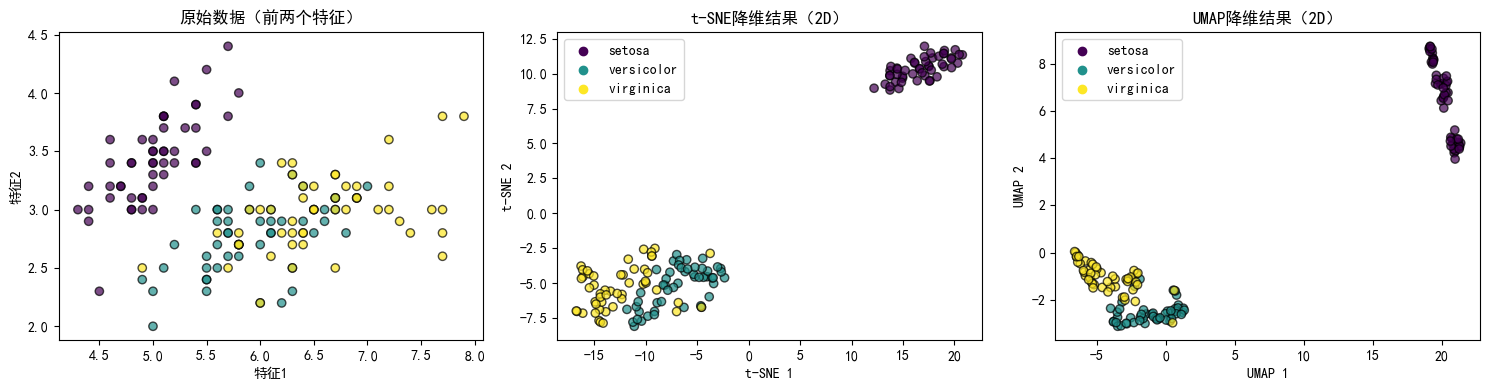

t-SNE不同参数对比：


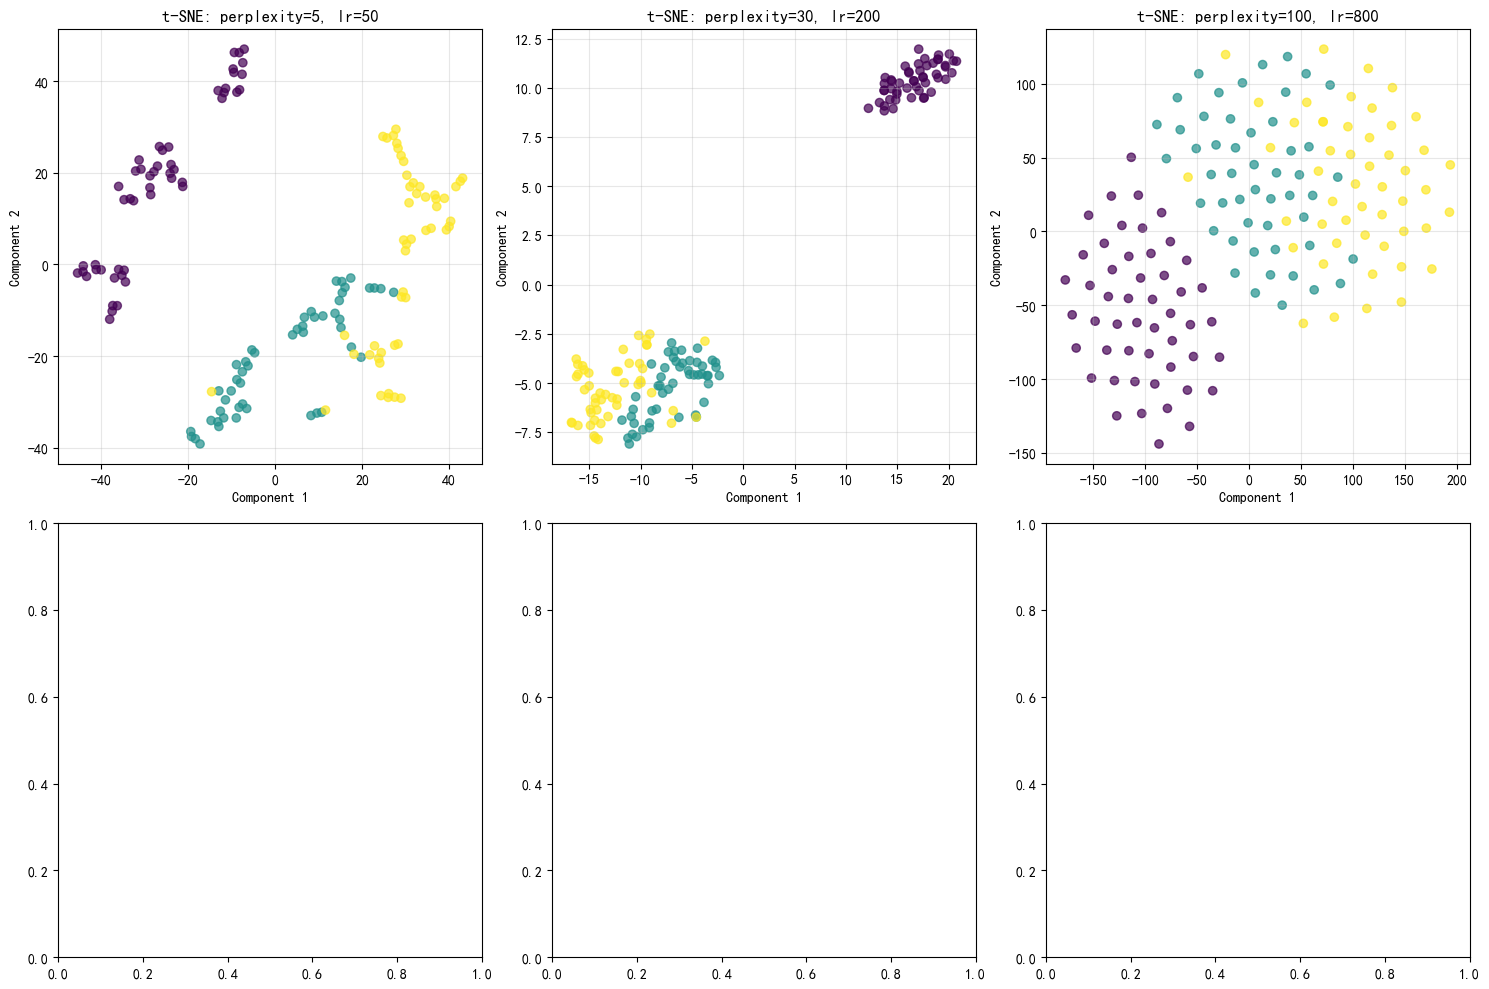

UMAP不同参数对比：


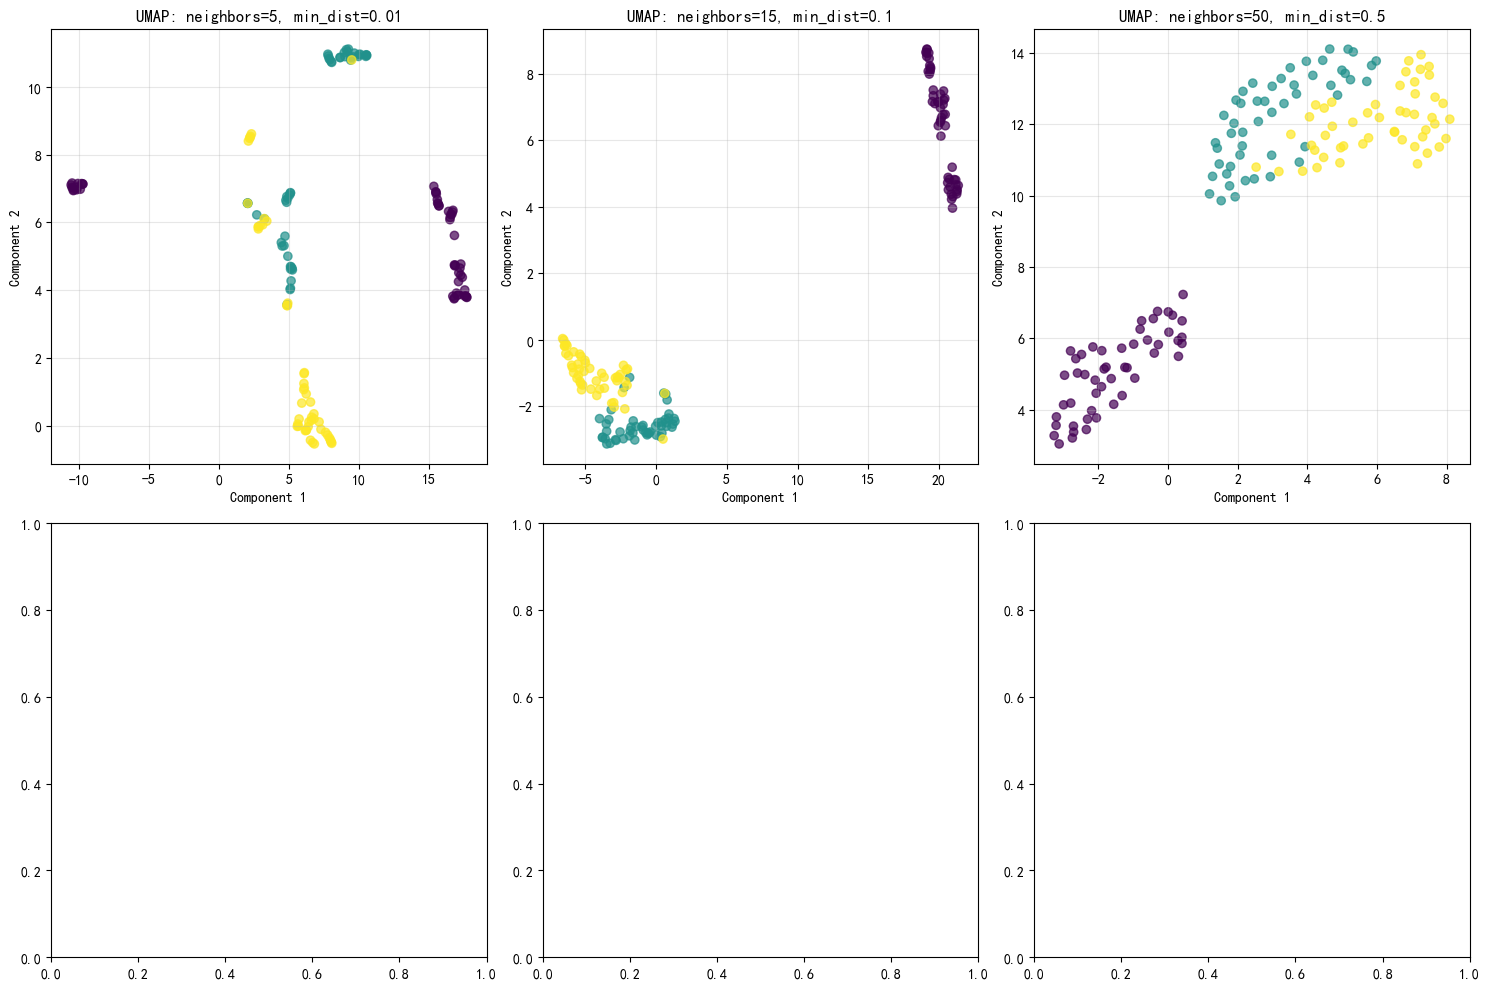


降维质量评估：
t-SNE 轮廓系数: 0.529
UMAP 轮廓系数: 0.565

模型保存和加载演示：


AttributeError: 'UMAP' object has no attribute 'save'

In [1]:
# %load 4-06.py
# 导入必要库
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['SimHei']  # 设置默认字体为黑体
plt.rcParams['axes.unicode_minus'] = False
from sklearn import datasets
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE
import umap.umap_ as umap
import warnings
warnings.filterwarnings('ignore')

# 1. 加载示例数据集
print("加载数据集...")
iris = datasets.load_iris()
X = iris.data  # 4维特征
y = iris.target  # 3个类别
target_names = iris.target_names

print(f"数据集形状: {X.shape}")
print(f"特征维度: {X.shape[1]}维")
print(f"类别数量: {len(np.unique(y))}个")
print(f"样本数量: {len(X)}个")

# 2. 数据标准化（重要步骤）
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3. t-SNE降维
print("\n执行t-SNE降维...")
tsne = TSNE(
    n_components=2,      # 降到2维
    perplexity=30,       # 困惑度（建议值5-50）
    learning_rate=200,   # 学习率
    n_iter=1000,         # 迭代次数
    random_state=42      # 随机种子（保证可重复性）
)
X_tsne = tsne.fit_transform(X_scaled)

# 4. UMAP降维
print("执行UMAP降维...")
reducer = umap.UMAP(
    n_components=2,      # 降到2维
    n_neighbors=15,      # 邻居数（类似perplexity）
    min_dist=0.1,        # 点之间的最小距离
    metric='euclidean',  # 距离度量
    random_state=42
)
X_umap = reducer.fit_transform(X_scaled)

# 5. 可视化结果
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# 原始数据的前两个特征（作为对比）
axes[0].scatter(X[:, 0], X[:, 1], c=y, cmap='viridis', alpha=0.7, edgecolors='k')
axes[0].set_title('原始数据（前两个特征）')
axes[0].set_xlabel('特征1')
axes[0].set_ylabel('特征2')

# t-SNE结果
scatter1 = axes[1].scatter(X_tsne[:, 0], X_tsne[:, 1], c=y, 
                          cmap='viridis', alpha=0.7, edgecolors='k')
axes[1].set_title('t-SNE降维结果（2D）')
axes[1].set_xlabel('t-SNE 1')
axes[1].set_ylabel('t-SNE 2')

# UMAP结果
scatter2 = axes[2].scatter(X_umap[:, 0], X_umap[:, 1], c=y, 
                          cmap='viridis', alpha=0.7, edgecolors='k')
axes[2].set_title('UMAP降维结果（2D）')
axes[2].set_xlabel('UMAP 1')
axes[2].set_ylabel('UMAP 2')

# 添加图例
for i, name in enumerate(target_names):
    axes[1].scatter([], [], label=name, color=plt.cm.viridis(i/2))
    axes[2].scatter([], [], label=name, color=plt.cm.viridis(i/2))
axes[1].legend()
axes[2].legend()

plt.tight_layout()
plt.show()

# 不同参数对比实验
def compare_parameters(method='tsne'):
    """比较不同参数对降维结果的影响"""
    
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    axes = axes.flatten()
    
    param_values = []
    
    if method == 'tsne':
        # t-SNE参数实验
        perplexities = [5, 30, 100]
        learning_rates = [50, 200, 800]
        
        for i, (perplexity, lr) in enumerate(zip(perplexities, learning_rates)):
            tsne = TSNE(n_components=2, perplexity=perplexity, 
                       learning_rate=lr, random_state=42)
            X_embedded = tsne.fit_transform(X_scaled)
            
            axes[i].scatter(X_embedded[:, 0], X_embedded[:, 1], 
                           c=y, cmap='viridis', alpha=0.7)
            axes[i].set_title(f't-SNE: perplexity={perplexity}, lr={lr}')
            axes[i].set_xlabel('Component 1')
            axes[i].set_ylabel('Component 2')
            axes[i].grid(True, alpha=0.3)
    
    else:
        # UMAP参数实验
        n_neighbors_list = [5, 15, 50]
        min_dist_list = [0.01, 0.1, 0.5]
        
        for i, (n_neighbors, min_dist) in enumerate(zip(n_neighbors_list, min_dist_list)):
            reducer = umap.UMAP(n_components=2, n_neighbors=n_neighbors,
                              min_dist=min_dist, random_state=42)
            X_embedded = reducer.fit_transform(X_scaled)
            
            axes[i].scatter(X_embedded[:, 0], X_embedded[:, 1], 
                           c=y, cmap='viridis', alpha=0.7)
            axes[i].set_title(f'UMAP: neighbors={n_neighbors}, min_dist={min_dist}')
            axes[i].set_xlabel('Component 1')
            axes[i].set_ylabel('Component 2')
            axes[i].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

print("t-SNE不同参数对比：")
compare_parameters(method='tsne')

print("UMAP不同参数对比：")
compare_parameters(method='umap')


# 3.1 降维质量评估（轮廓系数）
from sklearn.metrics import silhouette_score

def evaluate_embedding(X_embedded, y, method_name):
    """评估降维质量"""
    if len(np.unique(y)) > 1:
        score = silhouette_score(X_embedded, y)
        print(f"{method_name} 轮廓系数: {score:.3f}")
    return score

print("\n降维质量评估：")
tsne_score = evaluate_embedding(X_tsne, y, "t-SNE")
umap_score = evaluate_embedding(X_umap, y, "UMAP")

# 3.2 保存和加载模型（实际应用重要）
print("\n模型保存和加载演示：")
# t-SNE无法保存训练好的模型（每次需要重新训练）
# UMAP可以保存和加载
reducer.save('umap_model.pkl')
loaded_reducer = umap.UMAP()
loaded_reducer = umap.UMAP.load('umap_model.pkl')
print("UMAP模型已保存并重新加载")

# 3.3 大数据集处理技巧
def process_large_dataset(n_samples=10000, n_features=50):
    """模拟处理大数据集"""
    print(f"\n生成大数据集: {n_samples}个样本, {n_features}个特征")
    X_large = np.random.randn(n_samples, n_features)
    y_large = np.random.randint(0, 5, n_samples)
    
    # 对于大数据集，使用更高效的参数
    # t-SNE的近似算法
    tsne_fast = TSNE(
        n_components=2,
        method='barnes_hut',  # 使用Barnes-Hut近似算法
        angle=0.5,            # 速度与精度权衡
        n_iter=250,
        random_state=42
    )
    
    # UMAP本身就是为大数据集设计的
    umap_fast = umap.UMAP(
        n_components=2,
        n_neighbors=15,
        min_dist=0.1,
        metric='euclidean',
        n_epochs=200,         # 减少迭代次数
        random_state=42
    )
    
    print("大数据集降维完成")
    return tsne_fast, umap_fast




